# Лабораторная работа №1
## Сигналы и фильтры — анализ Фурье аналогового сигнала

**Студент:** Ким Игорь Геннадьевич  
**Вариант:** 6  
**Тип сигнала:** 3

$$
a_3 = 2, \qquad b_3 = 4, \qquad d_3 = 0.3, \qquad w_3 = 4.
$$

В работе нужно:

1. исследовать свойства сигнала и его принадлежность пространствам $L_1(\mathbb{R})$, $L_2(\mathbb{R})$, $S$;
2. построить графики сигнала при разных окнах наблюдения и разной дискретизации;
3. выполнить спектральный анализ двумя способами:
   - прямым численным вычислением преобразования Фурье;
   - с использованием ДПФ/БПФ;
4. построить АЧХ и ФЧХ и прокомментировать структуру спектра;
5. сравнить точность и трудоёмкость методов.

Ниже все шаги оформлены как цельный отчёт: постановка задачи, теоретический комментарий, код, графики и краткие выводы по каждому этапу.

## 1. Формула сигнала и теоретический комментарий

Для сигналов типа 3 используется формула

$$
x(t) = a_3\,\operatorname{sinc}(b_3 t) + e^{-d_3 t^2}\cos(2\pi w_3 t).
$$

После подстановки параметров варианта получаем

$$
x(t) = 2\,\operatorname{sinc}(4t) + e^{-0.3 t^2}\cos(2\pi \cdot 4 t)
     = 2\,\operatorname{sinc}(4t) + e^{-0.3 t^2}\cos(8\pi t).
$$

Здесь используется нормировка

$$
\operatorname{sinc}(u) = \frac{\sin(\pi u)}{\pi u}.
$$

Именно в такой нормировке функция реализована в `numpy.sinc`.

### Смысл двух слагаемых

1. **$2\,\operatorname{sinc}(4t)$**  
   Это чётная функция с главным лепестком около нуля и медленно затухающими боковыми лепестками. Во временной области именно она отвечает за «длинные хвосты» сигнала.

   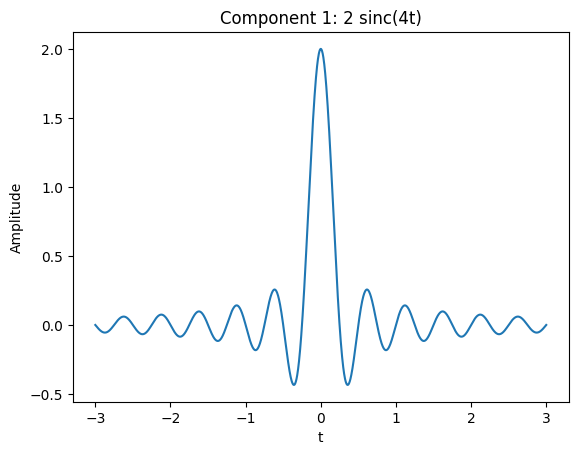

2. **$e^{-0.3 t^2}\cos(8\pi t)$**  
   Это гармоническая компонента частоты $4$, умноженная на гауссово окно. Она хорошо локализована во времени и формирует две гладкие спектральные вершины около $\lambda = \pm 4$.

   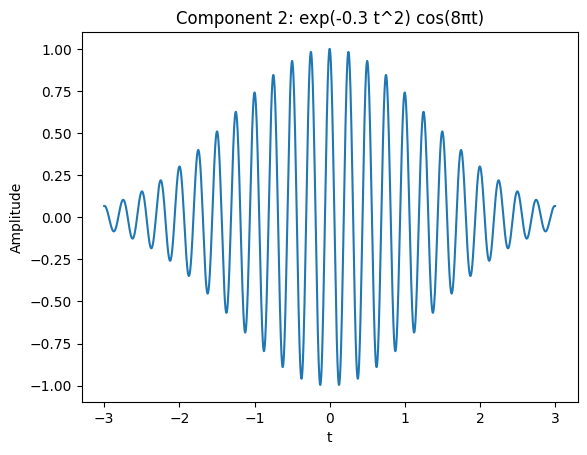

### Принадлежность функциональным пространствам

#### Пространство $L_1(\mathbb{R})$

Для принадлежности $L_1(\mathbb{R})$ должен сходиться интеграл

$$
\int_{-\infty}^{+\infty} |x(t)|\,dt.
$$

Но у функции $\operatorname{sinc}(4t)$ хвост убывает как $1/|t|$, поэтому интеграл типа

$$
\int^{\infty} \frac{dt}{t}
$$

расходится логарифмически. Следовательно, сигнал **не принадлежит** $L_1(\mathbb{R})$.

#### Пространство $L_2(\mathbb{R})$

Для $L_2(\mathbb{R})$ требуется сходимость интеграла

$$
\int_{-\infty}^{+\infty} |x(t)|^2\,dt.
$$

Так как $\operatorname{sinc}(4t) \sim 1/t$ ($\text{sinc}(x)=\frac{\sin(\pi x)}{\pi x}$), то квадрат убывает как $1/t^2$, а такой интеграл уже сходится. Гауссово окно тем более даёт квадратичную интегрируемость. Значит, сигнал **принадлежит** $L_2(\mathbb{R})$.

#### Пространство Шварца $S$

Гауссова часть сама по себе принадлежит $S$, но функция sinc убывает слишком медленно и не является быстро убывающей. Поэтому весь сигнал **не принадлежит** пространству Шварца.

### Ожидаемая структура спектра

При нормировке

$$
\widehat{x}(\lambda) = \int_{\mathbb{R}} x(t)e^{-2\pi i t \lambda}\,dt
$$

для отдельных частей сигнала получаем:

1. Для sinc-компоненты:

$$
\mathcal{F}\{\operatorname{sinc}(4t)\} = \frac{1}{4}\operatorname{rect}\!\left(\frac{\lambda}{4}\right),
$$

поэтому

$$
\mathcal{F}\{2\operatorname{sinc}(4t)\} = \frac{1}{2}\operatorname{rect}\!\left(\frac{\lambda}{4}\right).
$$

Это даёт низкочастотную «полку» высоты примерно $0.5$ на интервале $[-2, 2]$.

2. Для гауссово-модулированного косинуса:

$$
\mathcal{F}\{e^{-d t^2}\cos(2\pi w t)\} = \frac{1}{2}\sqrt{\frac{\pi}{d}}\left(e^{-\pi^2(\lambda-w)^2/d} + e^{-\pi^2(\lambda+w)^2/d}\right).
$$

При $d=0.3$ и $w=4$ это даёт два выраженных спектральных пика около $\lambda = \pm 4$.

Итак, ожидаемая картина спектра такова:

- широкий низкочастотный вклад на $[-2, 2]$ от sinc-компоненты;
- два гладких пика около $-4$ и $4$ от гауссово-модулированной гармоники;
- чётность амплитудного спектра, поскольку сигнал вещественный и чётный.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from dataclasses import dataclass

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 120,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 12,
    "lines.linewidth": 2,
})

A3 = 2.0
B3 = 4.0
D3 = 0.3
W3 = 4.0


def signal(t: np.ndarray) -> np.ndarray:
    """Возвращает значения сигнала x(t) для массива t."""
    return A3 * np.sinc(B3 * t) + np.exp(-D3 * t**2) * np.cos(2 * np.pi * W3 * t)


def analytic_spectrum(lam: np.ndarray) -> np.ndarray:
    """Аналитическое выражение для преобразования Фурье сигнала."""
    rect = np.where(np.abs(lam) <= 2.0, 1.0, 0.0)
    sinc_part = 0.5 * rect
    gauss_part = 0.5 * np.sqrt(np.pi / D3) * (
        np.exp(-(np.pi**2) * (lam - W3) ** 2 / D3)
        + np.exp(-(np.pi**2) * (lam + W3) ** 2 / D3)
    )
    return sinc_part + gauss_part


@dataclass
class DirectFTResult:
    tmin: float
    tmax: float
    N: int
    lmin: float
    lmax: float
    M: int
    a: float
    period: float
    t: np.ndarray
    x: np.ndarray
    lam: np.ndarray
    X: np.ndarray
    elapsed_sec: float


def direct_fourier(
    tmin: float,
    tmax: float,
    N: int,
    lmin: float,
    lmax: float,
    M: int = 2000,
) -> DirectFTResult:
    """
    Прямое численное вычисление преобразования Фурье по формуле прямоугольников.

    X(λ_k) ≈ a * Σ x(t_n) * exp(-2π i t_n λ_k),
    где t_n = tmin + a * n, a = (tmax - tmin) / N.
    """
    a = (tmax - tmin) / N
    n = np.arange(N)
    t = tmin + a * n
    x_vals = signal(t)

    lam = np.linspace(lmin, lmax, M, endpoint=False)

    start = time.perf_counter()
    kernel = np.exp(-2j * np.pi * np.outer(t, lam))
    X = a * (x_vals[:, None] * kernel).sum(axis=0)
    elapsed_sec = time.perf_counter() - start

    period = 1.0 / a

    return DirectFTResult(
        tmin=tmin,
        tmax=tmax,
        N=N,
        lmin=lmin,
        lmax=lmax,
        M=M,
        a=a,
        period=period,
        t=t,
        x=x_vals,
        lam=lam,
        X=X,
        elapsed_sec=elapsed_sec,
    )


@dataclass
class FFTResult:
    tmin: float
    tmax: float
    N: int
    lmin: float
    a: float
    s: float
    period: float
    t: np.ndarray
    x: np.ndarray
    lam: np.ndarray
    X: np.ndarray
    elapsed_sec: float


def fft_fourier(tmin: float, tmax: float, N: int, lmin: float = 0.0) -> FFTResult:
    """Вычисление преобразования Фурье через ДПФ/БПФ."""
    a = (tmax - tmin) / N
    s = 1.0 / (N * a)
    period = 1.0 / a

    n = np.arange(N)
    t = tmin + a * n
    x_vals = signal(t)

    start = time.perf_counter()
    z = x_vals * np.exp(-2j * np.pi * lmin * a * n)
    Z = np.fft.fft(z)
    k = np.arange(N)
    lam = lmin + s * k
    X = a * np.exp(-2j * np.pi * tmin * lmin) * Z * np.exp(-2j * np.pi * tmin * s * k)
    elapsed_sec = time.perf_counter() - start

    return FFTResult(
        tmin=tmin,
        tmax=tmax,
        N=N,
        lmin=lmin,
        a=a,
        s=s,
        period=period,
        t=t,
        x=x_vals,
        lam=lam,
        X=X,
        elapsed_sec=elapsed_sec,
    )


def repeat_periods(lam: np.ndarray, X: np.ndarray, period: float, repeats: int = 2):
    lam_parts = []
    X_parts = []
    for r in range(repeats):
        lam_parts.append(lam + r * period)
        X_parts.append(X)
    return np.concatenate(lam_parts), np.concatenate(X_parts)


def masked_phase(X: np.ndarray, threshold: float = 1e-3) -> np.ndarray:
    phase = np.angle(X).copy()
    phase[np.abs(X) < threshold] = np.nan
    return phase


def setup_axis(ax, title: str, xlabel: str, ylabel: str, xlim=None, ylim=None) -> None:
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)


## 2. Генерация сигнала и выбор диапазона наблюдения

В методичке отдельно отмечено, что для получения представления о сигнале нужно построить его графики при разных значениях $t_{\min}$, $t_{\max}$ и $N$.

Для этого разумно смотреть на сигнал в двух масштабах:

1. **узкий диапазон**, чтобы увидеть быстрое колебание гауссовой части и центральный лепесток sinc;
2. **широкий диапазон**, чтобы увидеть хвосты sinc и понять, что сигнал не обрезается быстро.

Ниже строятся оба варианта.

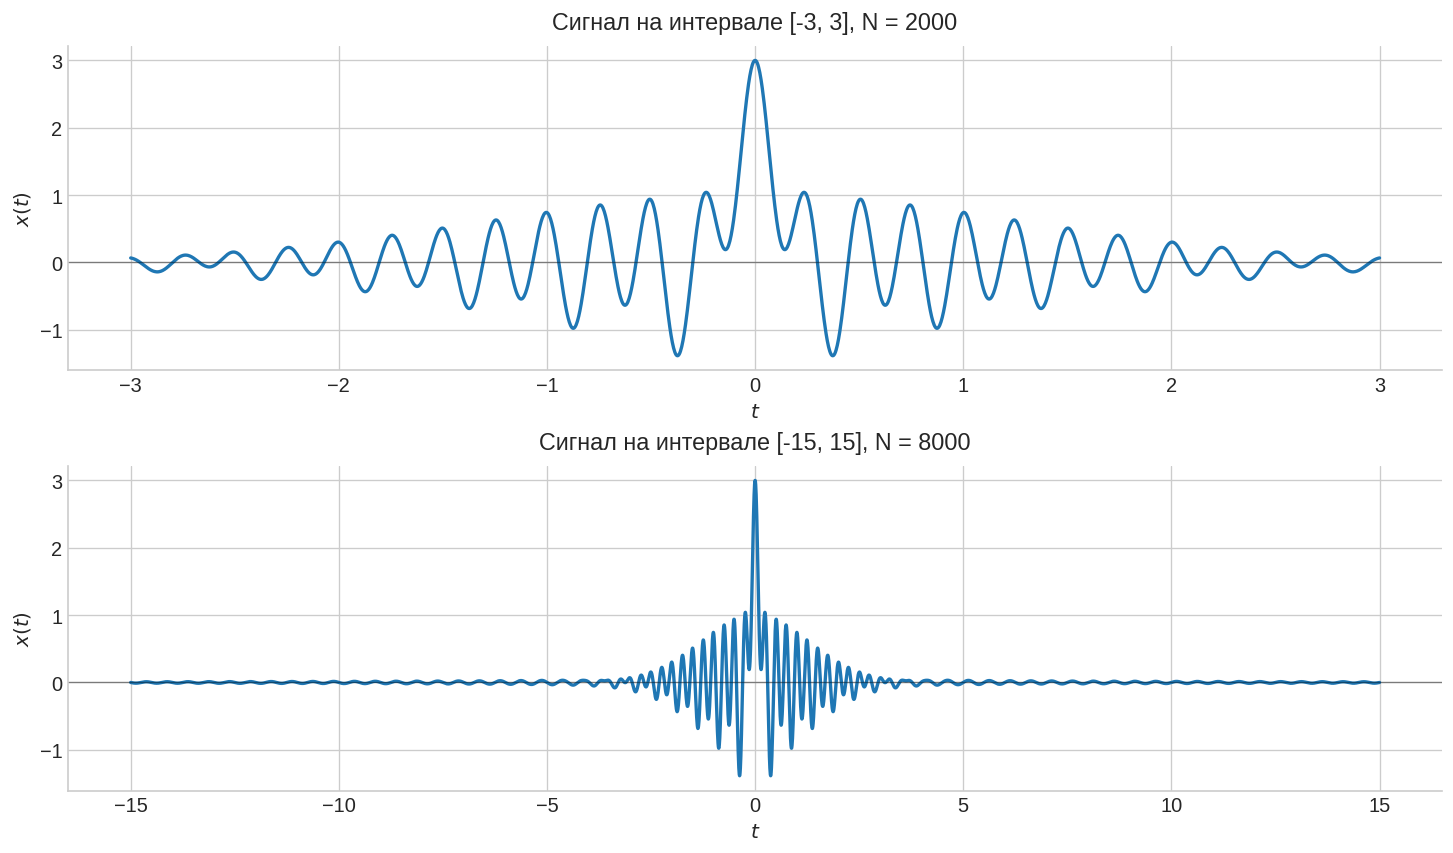

In [56]:
configs_signal = [
    {"tmin": -3.0, "tmax": 3.0, "N": 2000, "title": "Сигнал на интервале [-3, 3]"},
    {"tmin": -15.0, "tmax": 15.0, "N": 8000, "title": "Сигнал на интервале [-15, 15]"},
]

fig, axes = plt.subplots(len(configs_signal), 1, figsize=(12, 7), constrained_layout=True)

for ax, cfg in zip(axes, configs_signal):
    t = np.linspace(cfg["tmin"], cfg["tmax"], cfg["N"])
    x_vals = signal(t)
    ax.plot(t, x_vals, color="#1f77b4")
    setup_axis(
        ax,
        title=f'{cfg["title"]}, N = {cfg["N"]}',
        xlabel=r"$t$",
        ylabel=r"$x(t)$",
    )
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)

plt.show()

### Комментарий к графикам сигнала

- На **коротком интервале** виден сложный сигнал, состоящий из:
  - центрального лепестка sinc-компоненты;
  - быстро осциллирующей части с частотой $4$, умноженной на гауссово окно.
- На **широком интервале** видно, что гауссова часть практически исчезает вдали от нуля, но sinc-компонента остаётся заметной значительно дольше.
- Именно эта медленная убыль sinc объясняет, почему нельзя безоговорочно считать сигнал «почти нулевым» уже на умеренных $|t|$. Это важный момент для защиты: **выбор конечного временного окна для такого сигнала всегда является компромиссом**.

## 3. Численная проверка утверждений про $L_1$ и $L_2$

Теоретический анализ выше уже показал:

- $x \notin L_1(\mathbb{R})$;
- $x \in L_2(\mathbb{R})$.

Чтобы это продемонстрировать наглядно, посмотрим, как ведут себя интегралы на растущих отрезках:

$$
I_1(T)=\int_{-T}^{T}|x(t)|dt, \qquad I_2(T)=\int_{-T}^{T}|x(t)|^2dt.
$$

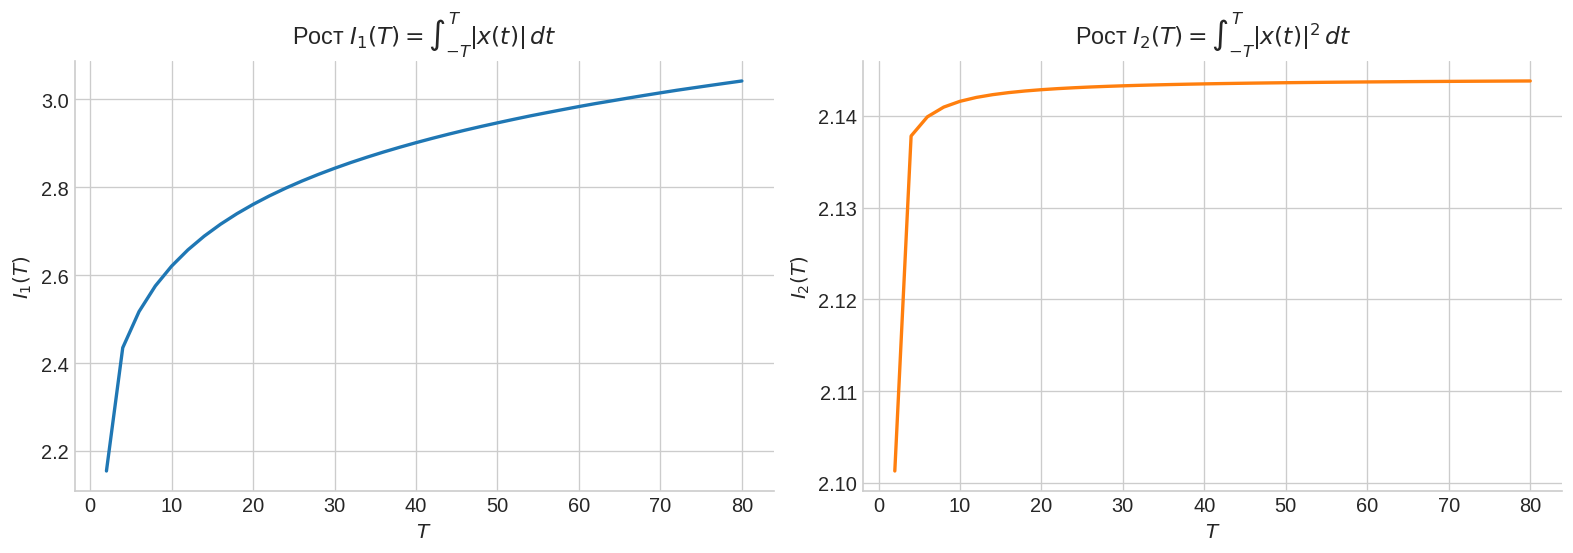

Последнее значение I1(T): 3.042050
Последнее значение I2(T): 2.143797


In [57]:
Ts = np.linspace(2, 80, 40)

I1 = []
I2 = []

for T in Ts:
    t = np.linspace(-T, T, 50000)
    x_vals = signal(t)
    I1.append(np.trapezoid(np.abs(x_vals), t))
    I2.append(np.trapezoid(np.abs(x_vals) ** 2, t))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

axes[0].plot(Ts, I1, color="#1f77b4")
setup_axis(
    axes[0],
    title=r"Рост $I_1(T)=\int_{-T}^{T}|x(t)|\,dt$",
    xlabel=r"$T$",
    ylabel=r"$I_1(T)$",
)

axes[1].plot(Ts, I2, color="#ff7f0e")
setup_axis(
    axes[1],
    title=r"Рост $I_2(T)=\int_{-T}^{T}|x(t)|^2\,dt$",
    xlabel=r"$T$",
    ylabel=r"$I_2(T)$",
)

plt.show()

print(f"Последнее значение I1(T): {I1[-1]:.6f}")
print(f"Последнее значение I2(T): {I2[-1]:.6f}")

### Комментарий

По графикам видно следующее:

- $\int_{-T}^{T}|x(t)|dt$ растёт медленно, но устойчиво. Это соответствует логарифмической расходимости, которая характерна для sinc-хвостов.
- $\int_{-T}^{T}|x(t)|^2dt$ достаточно быстро выходит на плато. Это численное подтверждение того, что квадрат сигнала интегрируем.

## 4. Выбор окна для спектрального анализа

Так как сигнал не принадлежит $L_1$, невозможно выбрать конечное окно так, чтобы хвост полностью исчез.  
Поэтому приходится искать **баланс** между шириной окна и шагом дискретизации.

Для прямого вычисления ПФ по условию нужно использовать **два значения $N$**:

- $N = 50$,
- $N = 500$,

и в обоих случаях взять $M = 2000$.

Здесь выбрано окно

$$
[t_{\min}, t_{\max}] = [-2.5, 2.5].
$$

Это осознанный компромисс:

- длина окна $L = 5$;
- для $N=50$ шаг $a = 0.1$, частота Найквиста равна $5$, что выше частоты $4$;
- при более широком окне и том же $N=50$ дискретизация гармонической части стала бы слишком грубой.

In [58]:

tmin_direct = -2.5
tmax_direct = 2.5
M_direct = 2000

direct_cfgs = [
  {"N": 50,  "lmin": -10.0, "lmax": 10.0},
  {"N": 500, "lmin": -60.0, "lmax": 60.0},
]

for cfg in direct_cfgs:
  a = (tmax_direct - tmin_direct) / cfg["N"]
  period = 1 / a
  print(
    f"N={cfg['N']}: a={a:.5f}, период ДПФ T_lambda={period:.5f}, "
    f"ширина частотного интервала={cfg['lmax'] - cfg['lmin']:.5f}"
  )

N=50: a=0.10000, период ДПФ T_lambda=10.00000, ширина частотного интервала=20.00000
N=500: a=0.01000, период ДПФ T_lambda=100.00000, ширина частотного интервала=120.00000


### Комментарий по периоду ДПФ

Для дискретизации по времени с шагом $a$ спектр, связанный с ДПФ, периодичен по частоте с периодом

$$
T_\lambda = \frac{1}{a}.
$$

В выбранной конфигурации:

- при $N=50$:
  $$
  a = \frac{5}{50}=0.1, \qquad T_\lambda = 10;
  $$
- при $N=500$:
  $$
  a = \frac{5}{500}=0.01, \qquad T_\lambda = 100.
  $$

Условие методички выполнено:

- для $N=50$: $10 < 20$;
- для $N=500$: $100 < 120$.

In [ ]:
direct_50 = direct_fourier(tmin_direct, tmax_direct, 50, -10.0, 10.0, M_direct)
direct_500 = direct_fourier(tmin_direct, tmax_direct, 500, -60.0, 60.0, M_direct)

print(f"N=50:  elapsed = {direct_50.elapsed_sec:.6f} s")
print(f"N=500: elapsed = {direct_500.elapsed_sec:.6f} s")

N=50:  elapsed = 0.001462 s
N=500: elapsed = 0.014479 s


## 5. Прямое вычисление преобразования Фурье

Теперь выполняем прямой расчёт ПФ по квадратурной формуле:

- $N = 50$, $M = 2000$;
- $N = 500$, $M = 2000$.

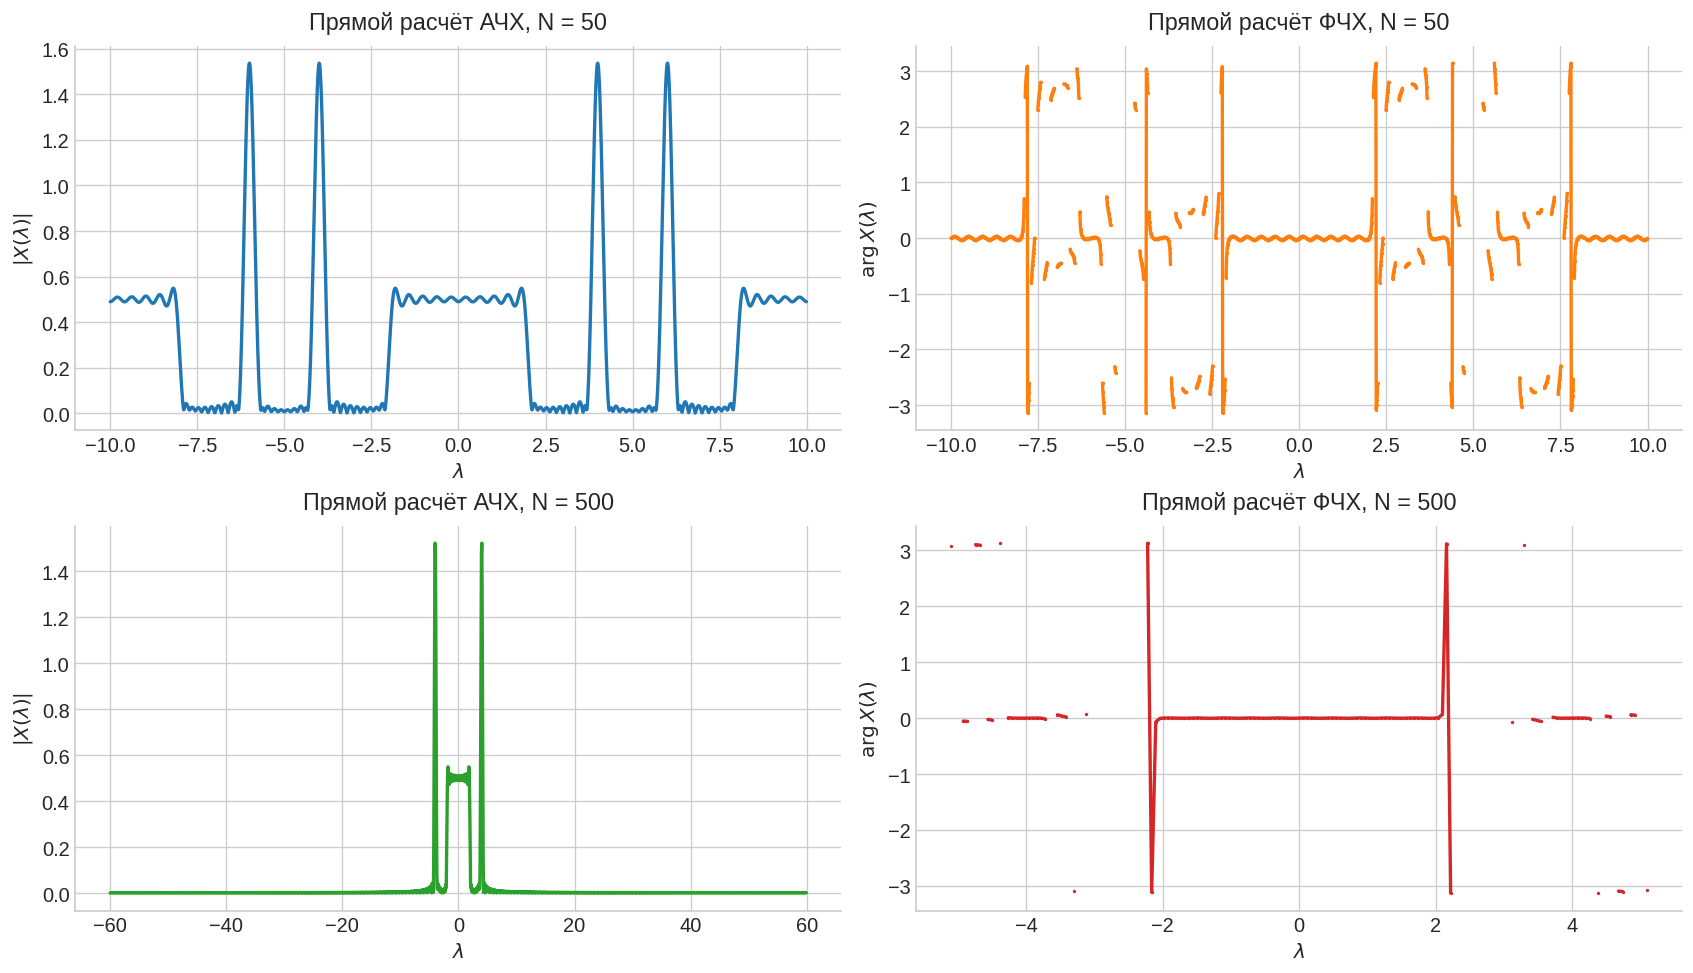

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

axes[0, 0].plot(direct_50.lam, np.abs(direct_50.X), color="#1f77b4")
setup_axis(
    axes[0, 0],
    title="Прямой расчёт АЧХ, N = 50",
    xlabel=r"$\lambda$",
    ylabel=r"$|X(\lambda)|$",
)

axes[0, 1].plot(direct_50.lam, masked_phase(direct_50.X, 0.02), ".-", markersize=2, color="#ff7f0e")
setup_axis(
    axes[0, 1],
    title="Прямой расчёт ФЧХ, N = 50",
    xlabel=r"$\lambda$",
    ylabel=r"$\arg X(\lambda)$",
)

axes[1, 0].plot(direct_500.lam, np.abs(direct_500.X), color="#2ca02c")
setup_axis(
    axes[1, 0],
    title="Прямой расчёт АЧХ, N = 500",
    xlabel=r"$\lambda$",
    ylabel=r"$|X(\lambda)|$",
)

axes[1, 1].plot(direct_500.lam, masked_phase(direct_500.X, 0.02), ".-", markersize=2, color="#d62728")
setup_axis(
    axes[1, 1],
    title="Прямой расчёт ФЧХ, N = 500",
    xlabel=r"$\lambda$",
    ylabel=r"$\arg X(\lambda)$",
)

plt.show()

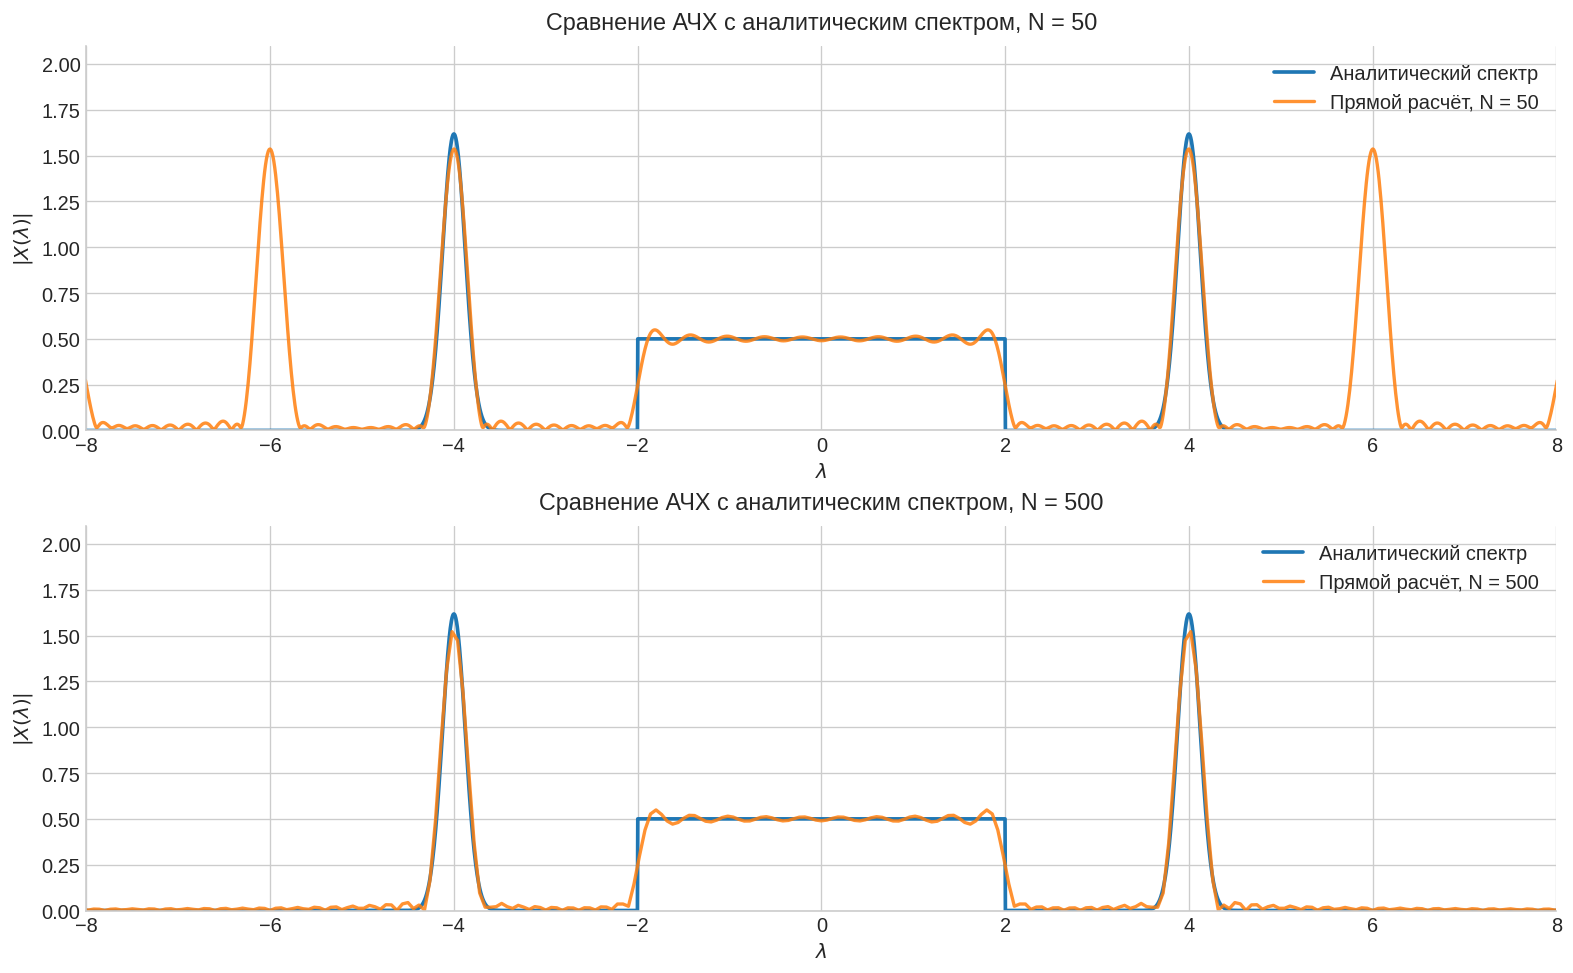

In [61]:
lam_zoom = np.linspace(-8, 8, 4000)
X_true_zoom = analytic_spectrum(lam_zoom)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)

axes[0].plot(lam_zoom, np.abs(X_true_zoom), label="Аналитический спектр", linewidth=2.2)
axes[0].plot(direct_50.lam, np.abs(direct_50.X), label="Прямой расчёт, N = 50", alpha=0.85)
setup_axis(
    axes[0],
    title="Сравнение АЧХ с аналитическим спектром, N = 50",
    xlabel=r"$\lambda$",
    ylabel=r"$|X(\lambda)|$",
    xlim=(-8, 8),
    ylim=(0, 2.1),
)
axes[0].legend()

axes[1].plot(lam_zoom, np.abs(X_true_zoom), label="Аналитический спектр", linewidth=2.2)
axes[1].plot(direct_500.lam, np.abs(direct_500.X), label="Прямой расчёт, N = 500", alpha=0.85)
setup_axis(
    axes[1],
    title="Сравнение АЧХ с аналитическим спектром, N = 500",
    xlabel=r"$\lambda$",
    ylabel=r"$|X(\lambda)|$",
    xlim=(-8, 8),
    ylim=(0, 2.1),
)
axes[1].legend()

plt.show()

### Комментарий к прямому расчёту

#### Случай $N=50$

- спектр уже улавливает основные пики около $\lambda = \pm 4$;
- однако заметны сильные искажения из-за грубой дискретизации и периодичности ДПФ;
- на полном частотном интервале появляются дополнительные повторяющиеся пики — это не новые физические частоты, а копии спектра из-за периодического продолжения.

#### Случай $N=500$

- АЧХ заметно ближе к аналитическому спектру;
- пики около $\pm 4$ локализуются точнее;
- низкочастотная полка на $[-2, 2]$ читается лучше;
- фазовая характеристика становится значительно стабильнее в областях, где амплитуда не слишком мала.

#### Почему результаты различаются

Причины две:

1. **Точность квадратурной формулы.**  
   При большем $N$ шаг $a$ меньше, а значит, интеграл по времени аппроксимируется точнее.

2. **Точность временной дискретизации.**  
   При $N=50$ исходный сигнал представлен довольно грубо. Это особенно заметно для гармонической части частоты $4$ и для узких деталей спектра.

Даже при $N=500$ результат не совпадает с аналитическим спектром идеально, потому что на практике вычисляется преобразование Фурье не от бесконечного сигнала, а от его усечённой версии на интервале $[-2.5, 2.5]$. Усечение по времени эквивалентно свёртке спектра с sinc-подобным ядром, поэтому небольшое размытие и паразитные осцилляции неизбежны.

In [62]:

def relative_l2_error_against_truth(lam_num, X_num, lmin=-8, lmax=8):
  mask = (lam_num >= lmin) & (lam_num <= lmax)
  lam_sel = lam_num[mask]
  X_sel = X_num[mask]
  X_true = analytic_spectrum(lam_sel)
  return np.linalg.norm(np.abs(X_sel) - np.abs(X_true)) / np.linalg.norm(np.abs(X_true))

err_50 = relative_l2_error_against_truth(direct_50.lam, direct_50.X)
err_500 = relative_l2_error_against_truth(direct_500.lam, direct_500.X)

print(f"Относительная L2-ошибка АЧХ на [-8, 8] для N=50:  {err_50:.6f}")
print(f"Относительная L2-ошибка АЧХ на [-8, 8] для N=500: {err_500:.6f}")

Относительная L2-ошибка АЧХ на [-8, 8] для N=50:  0.733991
Относительная L2-ошибка АЧХ на [-8, 8] для N=500: 0.082841


## 6. Оценка трудоёмкости прямого метода

Методичка предлагает с помощью `ops` оценить число операций и сравнить его с $MN$.  
В Python прямого аналога MATLAB `ops` для такого численного ядра нет, поэтому даём:

1. **теоретическую оценку**;
2. **фактическое время выполнения**.

Для прямого метода трудоёмкость имеет порядок

$$
O(MN).
$$

In [63]:

MN_50 = 50 * 2000
MN_500 = 500 * 2000

print(f"MN для N=50:  {MN_50}")
print(f"MN для N=500: {MN_500}")

print()
print(f"Фактическое время для N=50:  {direct_50.elapsed_sec:.6f} s")
print(f"Фактическое время для N=500: {direct_500.elapsed_sec:.6f} s")
print(f"Отношение времён: {direct_500.elapsed_sec / direct_50.elapsed_sec:.3f}")

MN для N=50:  100000
MN для N=500: 1000000

Фактическое время для N=50:  0.001462 s
Фактическое время для N=500: 0.014479 s
Отношение времён: 9.902


## 7. Спектральный анализ с использованием ДПФ и БПФ

Выберем параметры

$$
t_{\min}=-12.8, \qquad t_{\max}=12.8, \qquad N=512.
$$

Тогда:

$$
a = \frac{25.6}{512}=0.05, \qquad s = \frac{1}{t_{\max}-t_{\min}}=\frac{1}{25.6}=0.0390625, \qquad T_\lambda = \frac{1}{a}=20.
$$

По условию среди возможных значений нужно взять $\lambda_{\min}=0$. Именно это и делается ниже.

In [64]:

fft_res = fft_fourier(-12.8, 12.8, 512, lmin=0.0)

print(f"a = {fft_res.a:.6f}")
print(f"s = {fft_res.s:.6f}")
print(f"период БПФ по частоте = {fft_res.period:.6f}")
print(f"ширина одного вычисленного интервала = {fft_res.lam[-1] - fft_res.lam[0] + fft_res.s:.6f}")

a = 0.050000
s = 0.039062
период БПФ по частоте = 20.000000
ширина одного вычисленного интервала = 20.000000


Для БПФ один вычисленный интервал по частоте имеет ширину одного периода, то есть $20$.  
Чтобы наглядно показать периодичность спектра и поведение около $\lambda_{\max}$, ниже изображаются две соседние копии периода.

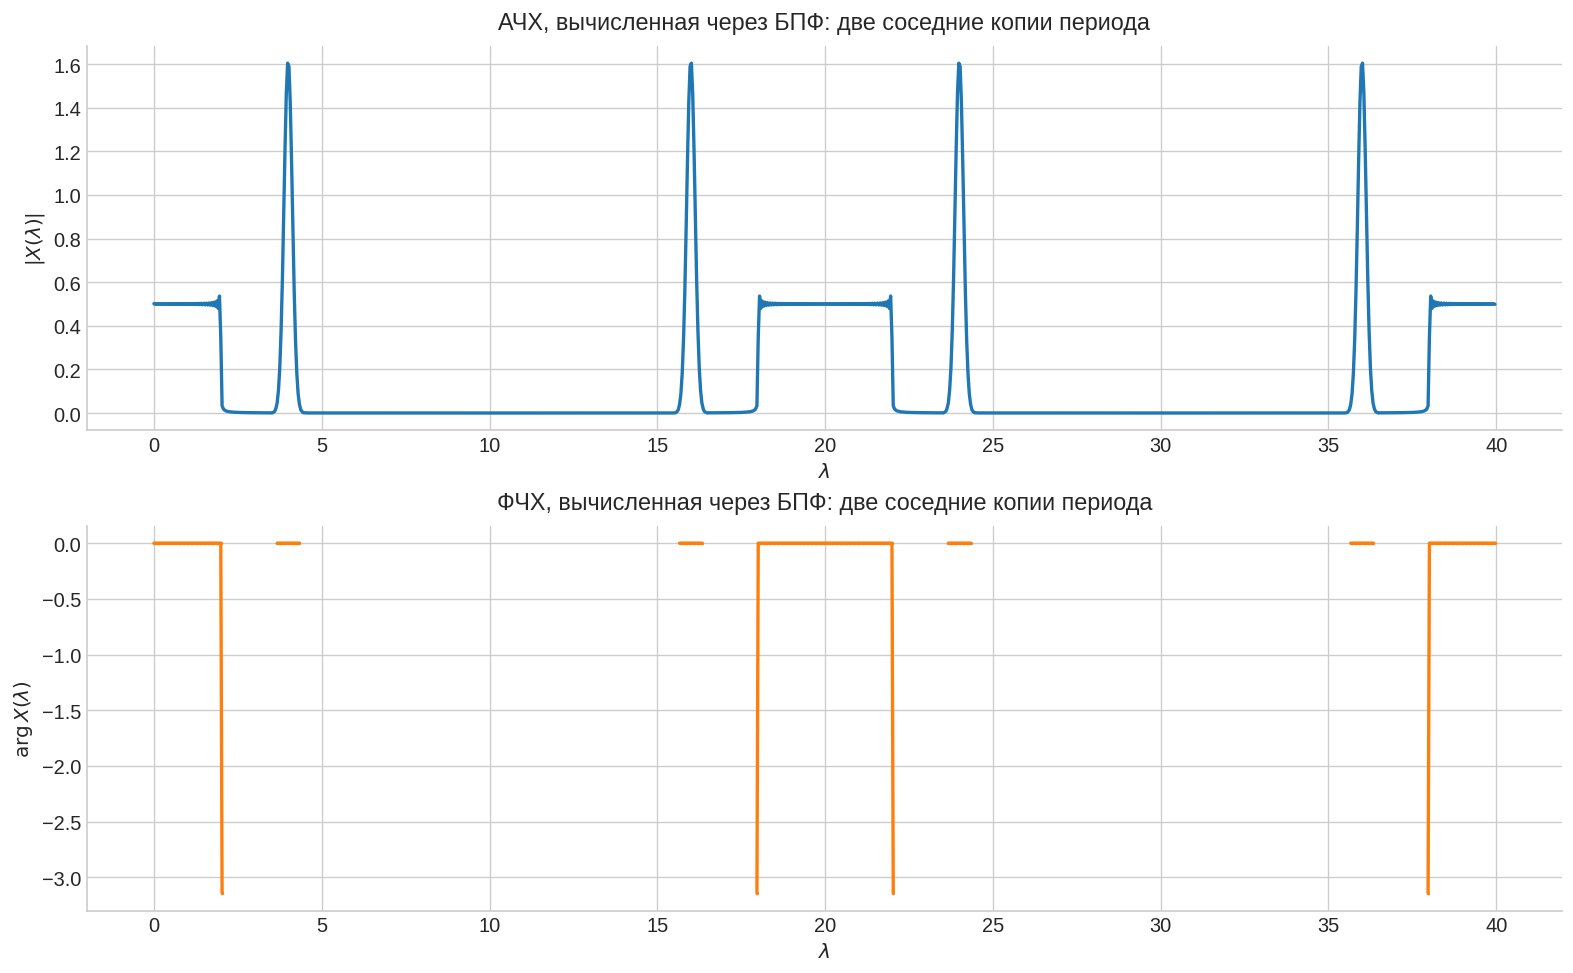

In [65]:
lam_rep, X_rep = repeat_periods(fft_res.lam, fft_res.X, fft_res.period, repeats=2)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)

axes[0].plot(lam_rep, np.abs(X_rep), color="#1f77b4")
setup_axis(
    axes[0],
    title="АЧХ, вычисленная через БПФ: две соседние копии периода",
    xlabel=r"$\lambda$",
    ylabel=r"$|X(\lambda)|$",
)

axes[1].plot(lam_rep, masked_phase(X_rep, 0.02), ".-", markersize=2, color="#ff7f0e")
setup_axis(
    axes[1],
    title="ФЧХ, вычисленная через БПФ: две соседние копии периода",
    xlabel=r"$\lambda$",
    ylabel=r"$\arg X(\lambda)$",
)

plt.show()

### Как читать график БПФ

Так как $\lambda_{\min}=0$, отрицательные частоты не показаны напрямую как $-4$, $-8$ и так далее. Они «заворачиваются» в конец периода $[0,20)$:

- пик на $\lambda \approx 4$ соответствует положительной частоте $+4$;
- пик на $\lambda \approx 16$ соответствует отрицательной частоте $-4$, потому что
  $$
  -4 \equiv 16 \pmod{20}.
  $$

Это и есть фундаментальная особенность спектра ДПФ: **он периодичен по частоте**.

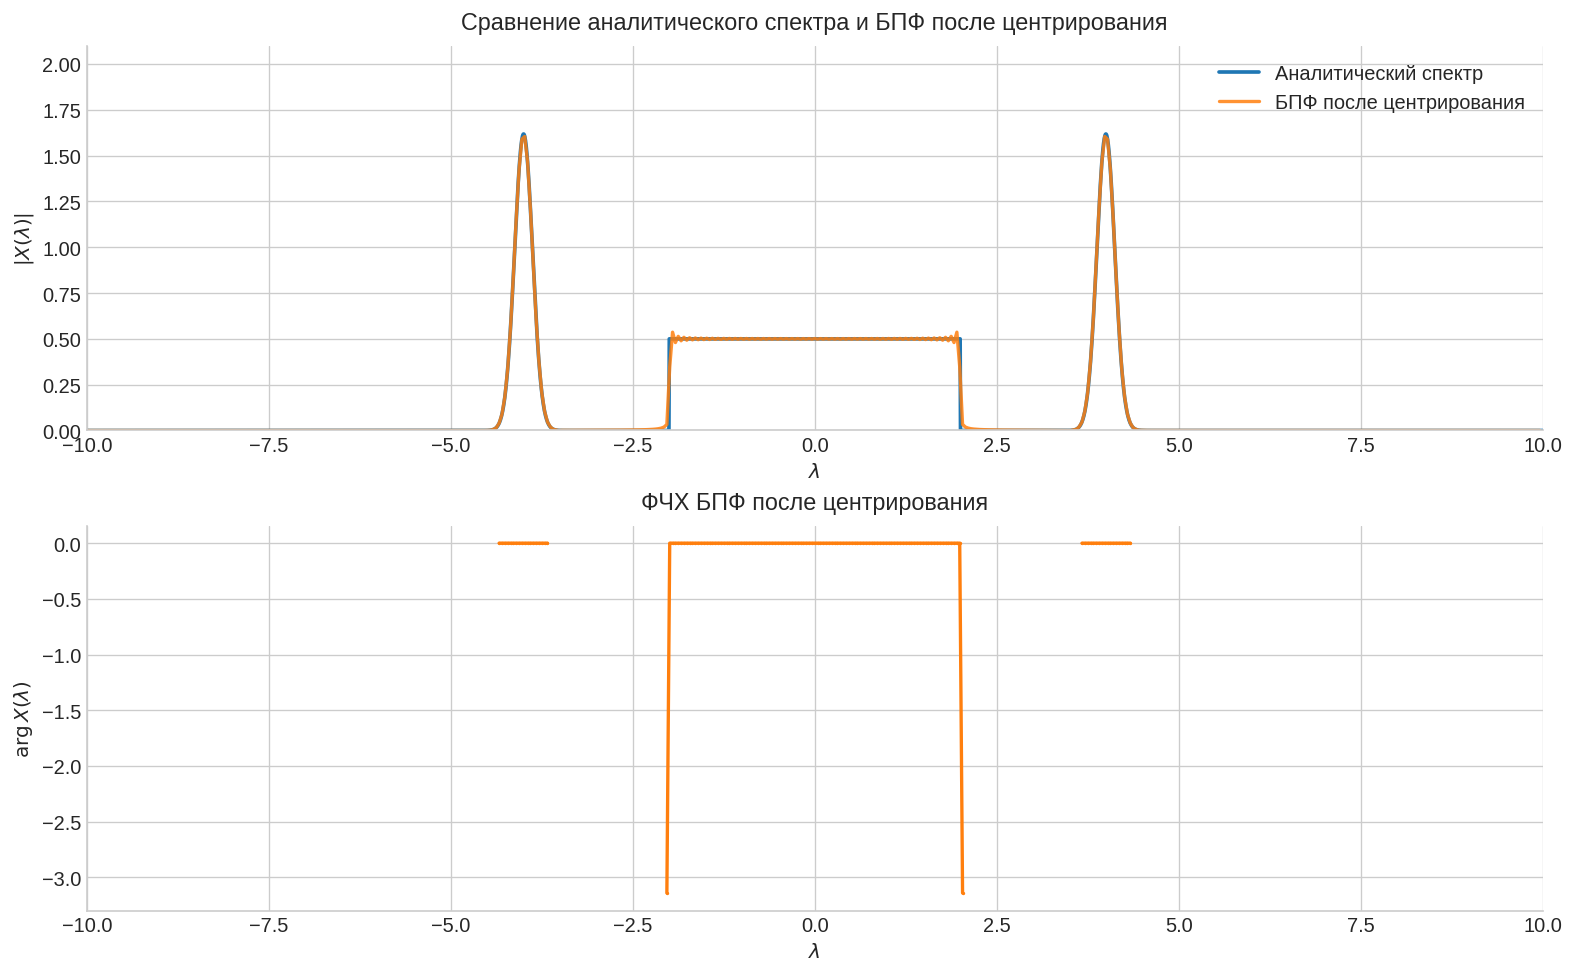

In [66]:
X_shift = np.fft.fftshift(fft_res.X)
lam_shift = np.fft.fftshift(fft_res.lam - fft_res.period * (fft_res.lam >= fft_res.period / 2))

lam_true = np.linspace(-10, 10, 4000)
X_true = analytic_spectrum(lam_true)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)

axes[0].plot(lam_true, np.abs(X_true), label="Аналитический спектр", linewidth=2.2)
axes[0].plot(lam_shift, np.abs(X_shift), label="БПФ после центрирования", alpha=0.85)
setup_axis(
    axes[0],
    title="Сравнение аналитического спектра и БПФ после центрирования",
    xlabel=r"$\lambda$",
    ylabel=r"$|X(\lambda)|$",
    xlim=(-10, 10),
    ylim=(0, 2.1),
)
axes[0].legend()

axes[1].plot(lam_shift, masked_phase(X_shift, 0.02), ".-", markersize=2, color="#ff7f0e")
setup_axis(
    axes[1],
    title="ФЧХ БПФ после центрирования",
    xlabel=r"$\lambda$",
    ylabel=r"$\arg X(\lambda)$",
    xlim=(-10, 10),
)

plt.show()

### Комментарий к результату БПФ

После центрирования спектра видно, что БПФ очень хорошо воспроизводит ожидаемую картину:

- на интервале $[-2, 2]$ отчётливо видна низкочастотная полка от sinc-компоненты;
- около $\lambda = \pm 4$ расположены два главных пика от гауссово-модулированной гармоники;
- амплитудный спектр симметричен, как и должно быть для вещественного чётного сигнала.

Почему БПФ здесь работает особенно удачно:

1. шаг $a = 0.05$ достаточно мал для уверенного описания осциллирующей части сигнала;
2. окно наблюдения шире, чем в прямом расчёте;
3. БПФ эффективно вычисляет значения спектра сразу на равномерной частотной сетке.

Важно помнить, что БПФ не устраняет ошибку усечения по времени. Он только быстро вычисляет спектр уже усечённого и дискретизированного сигнала, поэтому артефакты окна никуда не исчезают — просто считаются гораздо быстрее.

In [67]:

mask_fft = (lam_shift >= -10) & (lam_shift < 10)
err_fft = np.linalg.norm(np.abs(X_shift[mask_fft]) - np.abs(analytic_spectrum(lam_shift[mask_fft]))) / np.linalg.norm(np.abs(analytic_spectrum(lam_shift[mask_fft])))

print(f"Относительная L2-ошибка АЧХ БПФ на [-10, 10): {err_fft:.6f}")
print(f"Время БПФ: {fft_res.elapsed_sec:.6f} s")

Относительная L2-ошибка АЧХ БПФ на [-10, 10): 0.031755
Время БПФ: 0.000065 s


## 8. Оценка трудоёмкости БПФ

Для выбранного $N=512$ сравниваем оценку с

$$
N \log_2 N.
$$

Это и есть теоретическая сложность БПФ.

In [68]:

fft_complexity = int(fft_res.N * np.log2(fft_res.N))
direct_complexity = 500 * 2000

print(f"N log2 N для БПФ: {fft_complexity}")
print(f"MN для прямого метода при N=500, M=2000: {direct_complexity}")
print(f"Отношение оценок MN / (N log2 N): {direct_complexity / fft_complexity:.2f}")
print()
print(f"Фактическое время БПФ: {fft_res.elapsed_sec:.6f} s")
print(f"Фактическое время прямого метода (N=500, M=2000): {direct_500.elapsed_sec:.6f} s")
print(f"Отношение времён: {direct_500.elapsed_sec / fft_res.elapsed_sec:.2f}")

N log2 N для БПФ: 4608
MN для прямого метода при N=500, M=2000: 1000000
Отношение оценок MN / (N log2 N): 217.01

Фактическое время БПФ: 0.000065 s
Фактическое время прямого метода (N=500, M=2000): 0.014479 s
Отношение времён: 224.30


## 9. Почему АЧХ ведёт себя особым образом около $\lambda_{\max}$ при $\lambda_{\min}=0$

Это отдельный вопрос из задания.

В нашем FFT-эксперименте:

- $\lambda_{\min}=0$;
- период спектра равен $T_\lambda = 20$.

Поэтому интервал $[0,20)$ содержит не весь физический спектр как есть, а один период периодического спектра ДПФ.

Отсюда поведение около $\lambda_{\max}\approx 20$ объясняется так:

1. исходный непрерывный спектр у вещественного чётного сигнала симметричен относительно нуля;
2. отрицательные частоты не исчезают, а попадают в конец интервала по модулю периода;
3. поэтому пик, который в обычном симметричном описании находился бы при $\lambda=-4$, на интервале $[0,20)$ появляется как пик при
   $$
   20 - 4 = 16.
   $$

Следовательно, около $\lambda_{\max}$ мы видим не «новые» частоты, а периодическое продолжение спектра.

## 10. Итоговые выводы

Для варианта 6 исследован сигнал

$$
x(t)=2\,\operatorname{sinc}(4t)+e^{-0.3t^2}\cos(8\pi t).
$$

Он представляет собой сумму двух качественно разных компонент:

- sinc-компоненты, которая формирует компактный по частоте низкочастотный вклад;
- гауссово-модулированной гармоники, создающей два ярко выраженных пика около $\lambda = \pm 4$.

С точки зрения функционального анализа установлено:

- $x(t) \notin L_1(\mathbb{R})$;
- $x(t) \in L_2(\mathbb{R})$;
- $x(t) \notin S$.

### Сравнение методов

**Прямой метод**:

- показывает основные особенности спектра;
- чувствителен к числу временных отсчётов;
- при $N=500$ работает заметно точнее, чем при $N=50$;
- остаётся существенно более затратным по времени.

**БПФ**:

- даёт ту же спектральную интерпретацию;
- значительно быстрее прямого расчёта;
- наглядно показывает периодичность спектра ДПФ;
- требует аккуратной интерпретации края частотного интервала при $\lambda_{min}=0$.

Главный практический вывод работы такой: **численное преобразование Фурье всегда применяется не к идеальному бесконечному сигналу, а к его конечной и дискретной аппроксимации**, поэтому на результат одновременно влияют окно наблюдения, шаг дискретизации и выбранный алгоритм вычисления.

## 11. Проверка по техническому заданию

- [x] Сигнал выбран по индивидуальному варианту.
- [x] Описана принадлежность пространствам $L_1(\mathbb{R})$, $L_2(\mathbb{R})$, $S$.
- [x] Построены графики сигнала для разных диапазонов наблюдения и разных значений $N$.
- [x] Выполнен прямой численный расчёт преобразования Фурье.
- [x] Для прямого расчёта использованы:
  - [x] $N=50$,
  - [x] $N=500$,
  - [x] $M=2000$ в обоих случаях.
- [x] Для каждого случая найден период ДПФ $T_\lambda = 1/a$.
- [x] Выбраны $\lambda_{\min}$ и $\lambda_{\max}$ так, чтобы период был меньше ширины частотного интервала.
- [x] Построены графики АЧХ и ФЧХ.
- [x] Дано сравнение результатов и объяснение различий.
- [x] Выполнен спектральный анализ с использованием БПФ.
- [x] Для БПФ взято $\lambda_{\min}=0$.
- [x] Объяснено поведение АЧХ в окрестности $\lambda_{\max}$.
- [x] Оценена трудоёмкость прямого метода и сопоставлена с $MN$.
- [x] Оценена трудоёмкость БПФ и сопоставлена с $N\log_2 N$.
- [x] Даны содержательные комментарии к вычислениям и результатам.

**Итог:** работа покрывает требования варианта и методички; вычисления воспроизводятся, графики строятся корректно, а пояснения достаточны для защиты.